In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import cv2
from scipy.stats import entropy, kurtosis, skew
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.utils import class_weight as sk_class_weight

import tensorflow as tf
from keras import Input, models, layers, regularizers
from keras.callbacks import ModelCheckpoint
from keras.utils import image_dataset_from_directory
from keras.callbacks import ReduceLROnPlateau
from keras.callbacks import EarlyStopping
from keras.optimizers import AdamW
from keras.metrics import AUC, Precision, Recall

2025-11-26 17:08:04.551085: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-26 17:08:05.397429: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-26 17:08:07.972226: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Global configuration
SEED = 42                                        # Fixed random seed for reproducibility
BATCH_SIZE = 32                                  # Number of images per training batch
LEARNING_RATE = 1e-4                             # Initial learning rate for the optimizer
DATASET_ROOT = "./chest_xray/"                   # Set the dataset location base path
CHECKPOINT_PATH = "best_model_checkpoint.keras"  # File path to save the best model
ACTIVE_SCENARIO = "DEVELOPMENT"                  # Active scenario selected: "DEVELOPMENT", "STAGING", "PRODUCTION"

In [3]:
# Set random seeds for reproducibility across libraries
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
# Set paths for train and test datasets
train_dir = DATASET_ROOT + "train"
test_dir = DATASET_ROOT + "test"

In [ ]:
def load_dataset_df(train_root, test_root):
    """Build a DataFrame with columns: image_path, label, split."""
    records = []

    # Parse training split folders
    for label_name in os.listdir(train_root):
        label_dir = os.path.join(train_root, label_name)
        if not os.path.isdir(label_dir):
            continue

        for f in os.listdir(label_dir):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                records.append({
                    "image_path": os.path.join(label_dir, f),
                    "label": label_name,
                    "split": "train"
                })

    # Parse test split folders
    for label_name in os.listdir(test_root):
        label_dir = os.path.join(test_root, label_name)
        if not os.path.isdir(label_dir):
            continue

        for f in os.listdir(label_dir):
            if f.lower().endswith((".png", ".jpg", ".jpeg")):
                records.append({
                    "image_path": os.path.join(label_dir, f),
                    "label": label_name,
                    "split": "test"
                })

    return pd.DataFrame(records)

In [ ]:
DF_ORIGIN = load_dataset_df(train_dir, test_dir)
df_train = DF_ORIGIN[DF_ORIGIN.split == "train"]
df_train

,image_path,label,split
0,./chest_xray/train/NORMAL/NORMAL2-IM-1277-0001...,NORMAL,train
1,./chest_xray/train/NORMAL/NORMAL2-IM-1094-0001...,NORMAL,train
2,./chest_xray/train/NORMAL/IM-0236-0001.jpeg,NORMAL,train
3,./chest_xray/train/NORMAL/IM-0491-0001-0002.jpeg,NORMAL,train
4,./chest_xray/train/NORMAL/NORMAL2-IM-0587-0001...,NORMAL,train
...,...,...,...
5227,./chest_xray/train/PNEUMONIA/person1355_bacter...,PNEUMONIA,train
5228,./chest_xray/train/PNEUMONIA/person1263_bacter...,PNEUMONIA,train
5229,./chest_xray/train/PNEUMONIA/person1486_bacter...,PNEUMONIA,train
5230,./chest_xray/train/PNEUMONIA/person358_virus_7...,PNEUMONIA,train


/tmp/ipykernel_836/1510222288.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  counts = [class_counts[0], class_counts[1]]


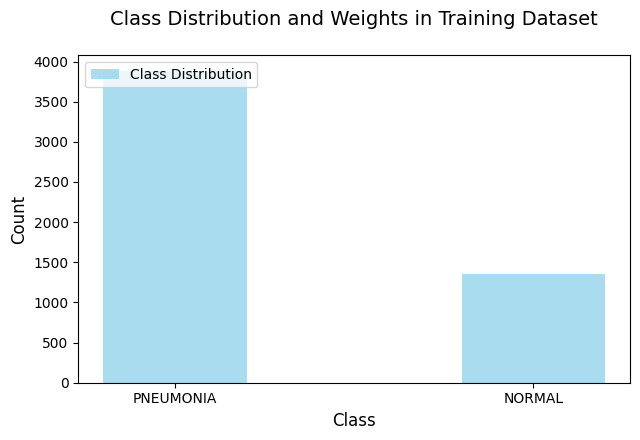

In [7]:
# Prepare data for plotting
classes = ['PNEUMONIA','NORMAL']
class_indices = [0, 1]

# Compute counts from all_labels
class_counts = df_train['label'].value_counts()
counts = [class_counts[0], class_counts[1]]

# Extract weights from dict
#weights = [class_weight_dict[0], class_weight_dict[1]]

# Plotting (unchanged)
fig, ax1 = plt.subplots(figsize=(6.5, 4.5))

ax1.bar(
	classes,
	counts,
	color='skyblue',
	alpha=0.7,
	label="Class Distribution",
	width=0.4,
	align='center'
)



ax1.set_title('Class Distribution and Weights in Training Dataset\n', fontsize=14)
ax1.set_xlabel('Class', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)

ax1.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# Load demo images, apply augmentation, and attach results to the DataFrame
def _load_image_gray(path, target_size=(256, 256)):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f'Could not read image: {path}')
    if target_size is not None:
        img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    # Normalization of the images
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=-1)  # H,W,1
    return img

In [30]:
paths = df_train['image_path'].tolist()
df_train['image'] = [_load_image_gray(p) for p in paths]

/tmp/ipykernel_836/2186248369.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['image'] = [_load_image_gray(p) for p in paths]


## Test Augmentation

In [ ]:
# Define augmentation
data_augmentation = models.Sequential([
    layers.RandomZoom(0.05, fill_mode="constant", fill_value=0, seed=SEED),
    layers.RandomTranslation(0.05, 0.05, fill_mode="constant", fill_value=0, seed=SEED),
    layers.RandomRotation(0.02, fill_mode="constant", fill_value=0, seed=SEED),
])

In [33]:
df_demo = pd.concat([
    df_train[df_train['label'] == "NORMAL"].iloc[[6]],
    df_train[df_train['label'] == "PNEUMONIA"].iloc[[10]]
])
df_demo

,image_path,label,split,image
6,./chest_xray/train/NORMAL/IM-0679-0001.jpeg,NORMAL,train,"[[[0.14509805], [0.2627451], [0.3882353], [0.3..."
1359,./chest_xray/train/PNEUMONIA/person1581_bacter...,PNEUMONIA,train,"[[[0.07450981], [0.08235294], [0.09411765], [0..."


In [31]:
df_train

,image_path,label,split,image
0,./chest_xray/train/NORMAL/NORMAL2-IM-1277-0001...,NORMAL,train,"[[[0.27450982], [0.29803923], [0.4862745], [0...."
1,./chest_xray/train/NORMAL/NORMAL2-IM-1094-0001...,NORMAL,train,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
2,./chest_xray/train/NORMAL/IM-0236-0001.jpeg,NORMAL,train,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
3,./chest_xray/train/NORMAL/IM-0491-0001-0002.jpeg,NORMAL,train,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
4,./chest_xray/train/NORMAL/NORMAL2-IM-0587-0001...,NORMAL,train,"[[[0.011764706], [0.011764706], [0.011764706],..."
...,...,...,...,...
5227,./chest_xray/train/PNEUMONIA/person1355_bacter...,PNEUMONIA,train,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
5228,./chest_xray/train/PNEUMONIA/person1263_bacter...,PNEUMONIA,train,"[[[0.2509804], [0.24705882], [0.27450982], [0...."
5229,./chest_xray/train/PNEUMONIA/person1486_bacter...,PNEUMONIA,train,"[[[0.16862746], [0.16470589], [0.14901961], [0..."
5230,./chest_xray/train/PNEUMONIA/person358_virus_7...,PNEUMONIA,train,"[[[0.015686275], [0.019607844], [0.023529412],..."


In [37]:
demo_stack = np.stack(df_demo['image'], axis=0)

# Convert to tensor and apply the Keras augmentation layers (in training mode)
demo_tensor = tf.convert_to_tensor(demo_stack)
demo_aug_tensor = data_augmentation(demo_tensor, training=True)
demo_aug = demo_aug_tensor.numpy()

# Build a new DataFrame with original and augmented image arrays attached
df_demo_aug = df_demo.reset_index(drop=True).copy()
df_demo_aug['aug_image'] = [img for img in demo_aug]

# Show the DataFrame to confirm columns exist
df_demo_aug

,image_path,label,split,image,aug_image
0,./chest_xray/train/NORMAL/IM-0679-0001.jpeg,NORMAL,train,"[[[0.14509805], [0.2627451], [0.3882353], [0.3...","[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."
1,./chest_xray/train/PNEUMONIA/person1581_bacter...,PNEUMONIA,train,"[[[0.07450981], [0.08235294], [0.09411765], [0...","[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."


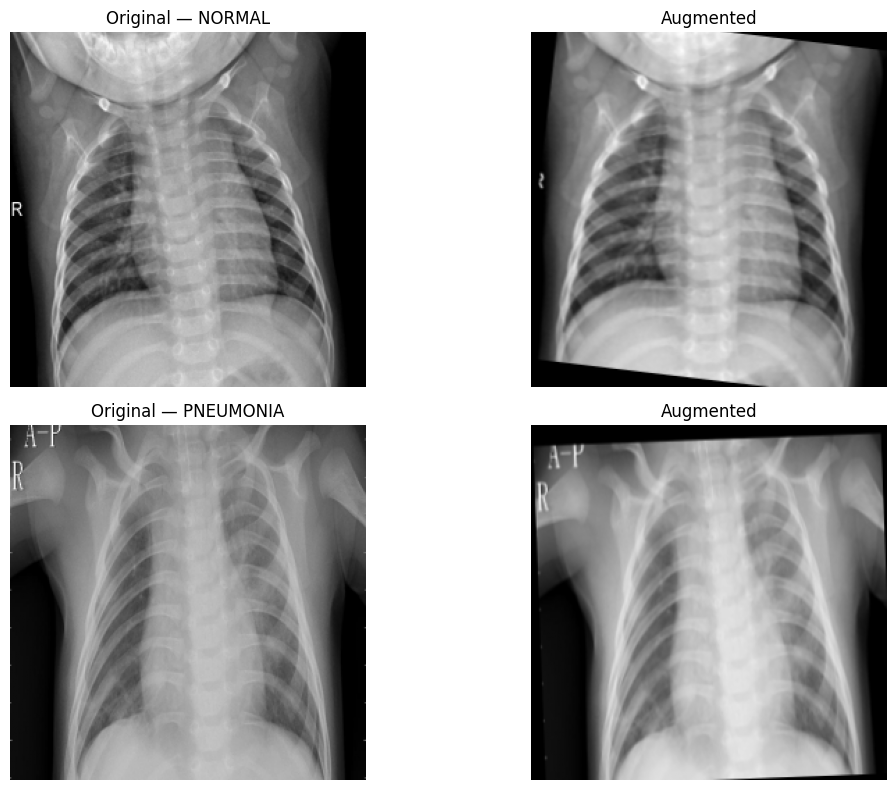

In [38]:

n = len(df_demo_aug)
cols = 2
rows = n
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))

for i in range(n):
    orig = df_demo_aug.loc[i, 'image']
    aug = df_demo_aug.loc[i, 'aug_image']

    ax_orig = axes[i, 0] if rows > 1 else axes[0]
    ax_aug = axes[i, 1] if rows > 1 else axes[1]

    ax_orig.imshow(orig[:, :, 0], cmap='gray')
    ax_orig.set_title(f"Original — {df_demo_aug.loc[i, 'label']}")
    ax_orig.axis('off')

    ax_aug.imshow(aug[:, :, 0], cmap='gray')
    ax_aug.set_title('Augmented')
    ax_aug.axis('off')

plt.tight_layout()
plt.show()

## Apply Augmentation

In [40]:
normal_df = df_train[df_train['label'] == 'NORMAL'].reset_index(drop=True)
print(f'Found {len(normal_df)} NORMAL samples to augment.')

# Aly augmentation by batches for computer performance reasons
batch_size = 64
augmented_rows = []

# Process NORMAL images in batches
for start in range(0, len(normal_df), batch_size):
    batch = normal_df.iloc[start:start + batch_size]
    imgs = batch['image'].tolist()  # already normalized arrays H,W,1

    # Stack and convert to tensor
    try:
        batch_arr = np.stack(imgs, axis=0)
    except Exception as e:
        raise RuntimeError(f'Error stacking images for batch starting at {start}: {e}')

    batch_tensor = tf.convert_to_tensor(batch_arr)

    # Apply augmentation (stochastic, training=True)
    aug_tensor = data_augmentation(batch_tensor, training=True)
    aug_imgs = aug_tensor.numpy()

    # Build augmented rows keeping metadata from originals
    for i_img, aug_img in enumerate(aug_imgs):
        orig_row = batch.iloc[i_img].copy()
        orig_row['augmented'] = True
        orig_row['image_array'] = aug_img
        orig_row['image_path_aug'] = str(orig_row.get('image_path', '')) + '::aug'
        augmented_rows.append(orig_row)

# Prepare base DataFrame (originals)
df_train_base = df_train.copy()
df_train_base['augmented'] = False
if 'image_array' not in df_train_base.columns:
    df_train_base['image_array'] = None

# Populate image_array for NORMAL originals from preloaded `image` column
normal_mask = df_train_base['label'] == 'NORMAL'
# Assign values, ensure shapes align
df_train_base.loc[normal_mask, 'image_array'] = df_train_base.loc[normal_mask, 'image'].values

# Create DataFrame from augmented rows and concatenate
df_augmented = pd.DataFrame(augmented_rows)
df_train_aug = pd.concat([df_train_base, df_augmented], ignore_index=True, sort=False)

Found 1349 NORMAL samples to augment.



Counts after augmenting NORMAL class (pixel-level augmentations appended):
 {'PNEUMONIA': 3883, 'NORMAL': 2698}


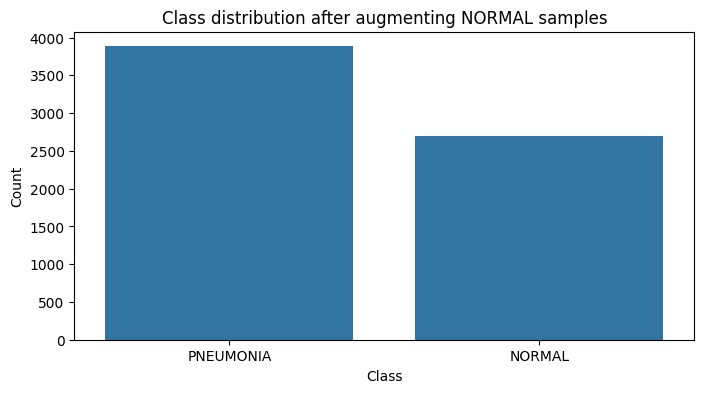

In [41]:
# Show new distribution
counts = df_train_aug['label'].value_counts()
print('\nCounts after augmenting NORMAL class (pixel-level augmentations appended):\n', counts.to_dict())

plt.figure(figsize=(8,4))
sns.barplot(x=counts.index, y=counts.values)
plt.title('Class distribution after augmenting NORMAL samples')
plt.ylabel('Count')
plt.xlabel('Class')
plt.show()

In [29]:
df_train_aug

,image_path,label,split,augmented,image_array,imgs
0,./chest_xray/train/NORMAL/NORMAL2-IM-1277-0001...,NORMAL,train,False,None,NaN
1,./chest_xray/train/NORMAL/NORMAL2-IM-1094-0001...,NORMAL,train,False,None,NaN
2,./chest_xray/train/NORMAL/IM-0236-0001.jpeg,NORMAL,train,False,None,NaN
3,./chest_xray/train/NORMAL/IM-0491-0001-0002.jpeg,NORMAL,train,False,None,NaN
4,./chest_xray/train/NORMAL/NORMAL2-IM-0587-0001...,NORMAL,train,False,None,NaN
...,...,...,...,...,...,...
6576,./chest_xray/train/NORMAL/IM-0712-0001.jpeg,NORMAL,train,True,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...","[[[0.023529412], [0.078431375], [0.101960786],..."
6577,./chest_xray/train/NORMAL/NORMAL2-IM-1347-0001...,NORMAL,train,True,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...","[[[0.25882354], [0.28627452], [0.29803923], [0..."
6578,./chest_xray/train/NORMAL/NORMAL2-IM-0900-0001...,NORMAL,train,True,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...","[[[0.0], [0.0], [0.0], [0.0], [0.003921569], [..."
6579,./chest_xray/train/NORMAL/NORMAL2-IM-1333-0001...,NORMAL,train,True,"[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0...","[[[0.0], [0.0], [0.0], [0.0], [0.0], [0.0], [0..."


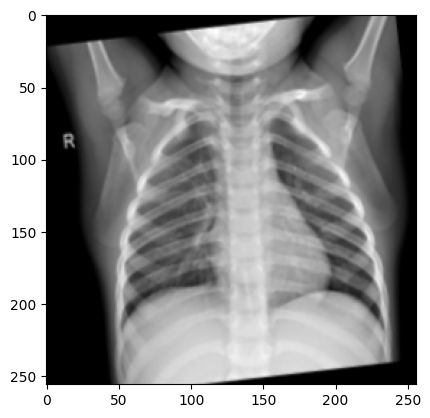

In [26]:
plt.imshow(df_train_aug.image_array[6576],cmap="gray")
plt.show()

## Data Pre-Processing